# Amplitude Envelope

In [21]:
import librosa
import librosa.display as lib_dis
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# load audio files

debussy = r"C:\Users\USER\ipnyb files\Machine Learning\Audio processing\datasets\Debussy,__Dr_Gradus__from_Childrens_Corner,_bars_36-43.wav"

In [3]:
ipd.Audio(debussy)

In [4]:
debussy, sr = librosa.load(debussy)

In [6]:
debussy.size

538624

In [8]:
sample_duration = 1/sr
print(f"Duration of one sample is : {sample_duration : .6f} seconds")

Duration of one sample is :  0.000045 seconds


In [11]:
# duration of the audio 
duration = sample_duration * debussy.size
duration

24.427392290249433

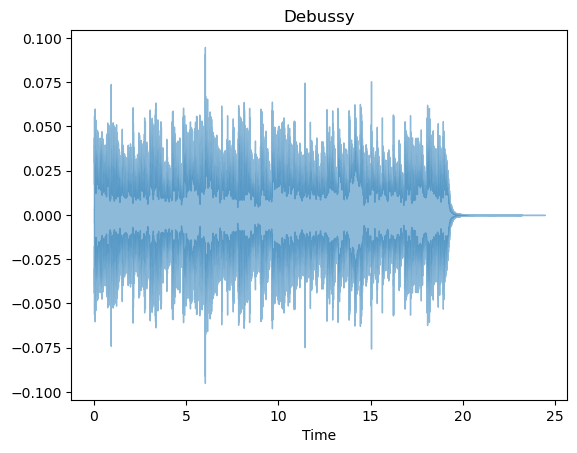

In [20]:
# visualize the waveforms

lib_dis.waveshow(debussy, alpha=0.5)
plt.title("Debussy")
# plt.ylim((-1, 1))
plt.show()

In [28]:
FRAME_SIZE = 1024
HOP_LENGTH = 512

# calculate amplitude envelope

def amp_envelope(signal, frame_size, hop_length):
    amp_envelope = []
    
    # calculate AE for each frame 
    for i in range(0, len(signal), hop_length):
        curr_frame_AE = max(signal[i:i+frame_size])
        amp_envelope.append(curr_frame_AE)

    return np.array(amp_envelope)

In [29]:
ae_debussy = amp_envelope(debussy, FRAME_SIZE, HOP_LENGTH)
len(ae_debussy)

1052

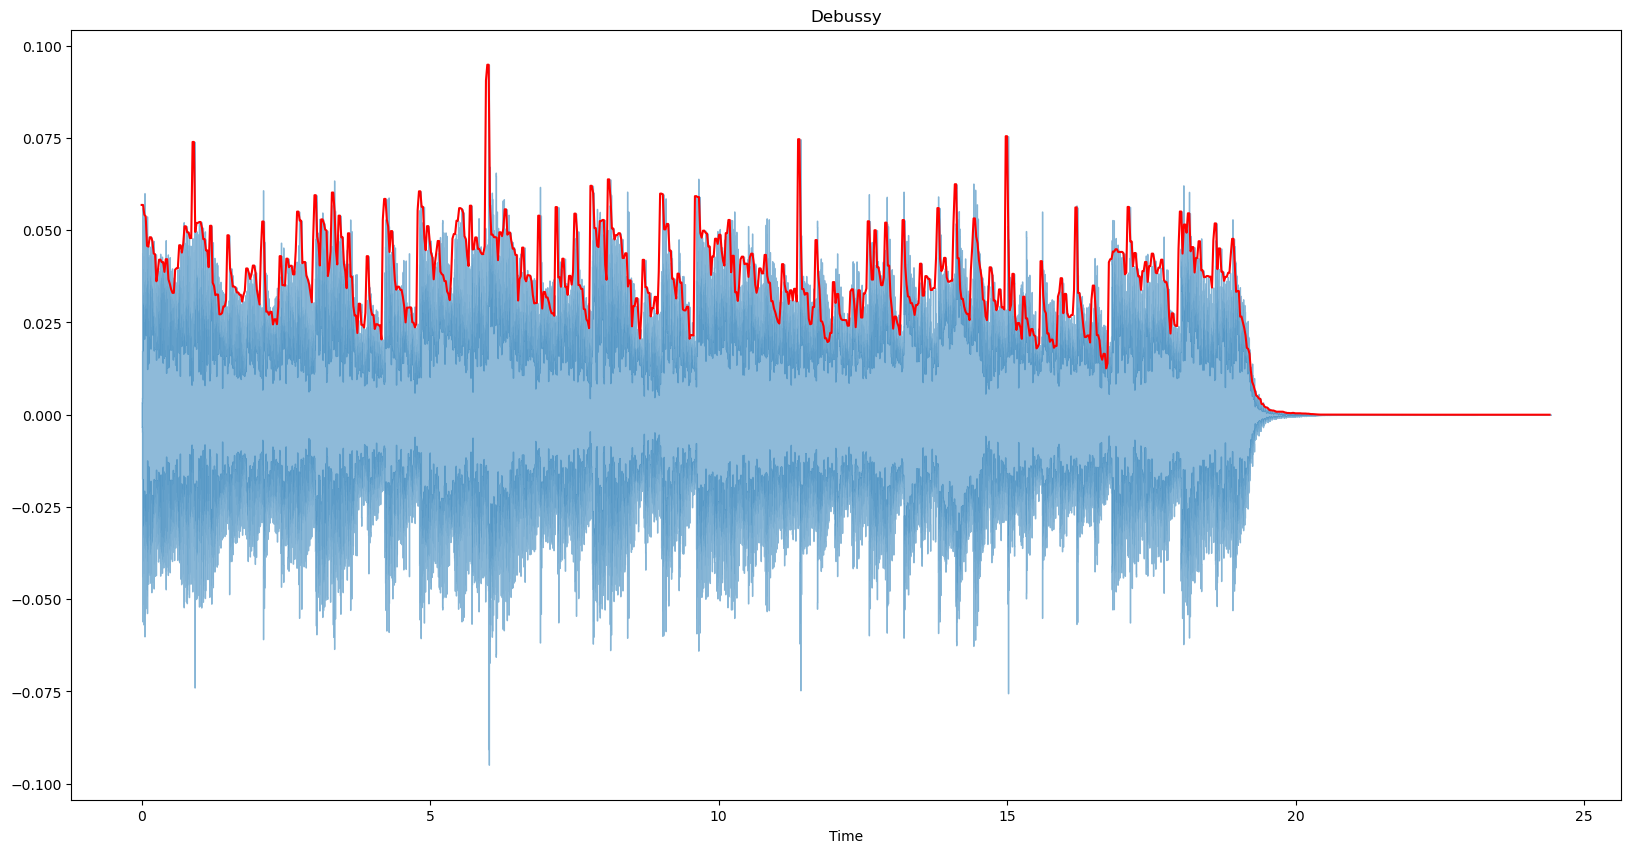

In [ ]:
# visualilze the AE

frames = range(0, ae_debussy.size)
t = librosa.frames_to_time(frames, hop_length=HOP_LENGTH)

plt.figure(figsize=(20, 10))
lib_dis.waveshow(debussy, alpha=0.5)
plt.plot(t, ae_debussy, color='r')
plt.title("Debussy")
plt.show()